# Capstone Project: Pitakado Dataset


# Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Apakah hari event (seperti Valentine dan Birthday) memberikan peningkatan penjualan yang signifikan dibanding hari biasa, dan berapa persen rata-rata peningkatan yang terjadi?
- Pertanyaan 2: Ketika event berlangsung, produk mana yang memberikan profit tertinggi antara kategori Bouquet dan Frame, serta berapa selisih margin keuntungannya?
- Pertanyaan 3: Pada bulan apa terjadi puncak penjualan tertinggi dan terendah dalam periode pencatatan, dan bagaimana pola ini digunakan untuk mengoptimalkan persiapan stok?
- Pertanyaan 4: Bahan baku apa saja yang memiliki total biaya tertinggi dan frekuensi pembelian paling sering, sehingga perlu diprioritaskan dalam manajemen stok untuk efisiensi operasional?

# Import Library/Packages yang Digunakan

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling

## Gathering Data

Langkah pertama adalah memuat dataset ke dalam environment notebook dengan mengupload file yang telah dikumpulkan dari hasil wawancara bersama pemilik UMKM Pitakado yang berupa data **Penjualan** dan data **Pembelian Bahan Baku** operasional. Kita perlu melihat beberapa baris pertama data untuk mendapatkan gambaran umum mengenai fitur-fitur (kolom) yang tersedia.

Dataset **"UMKM Pitakado Sales & Inventory Tracker"** adalah rekaman data operasional historis dari sebuah bisnis ritel skala kecil menengah (UMKM) yang berfokus pada produk gifting seperti buket bunga, buket snack, dan frame foto.

Dataset ini mencatat pergerakan transaksi harian selama kurang lebih satu kuartal awal (Januari - pertengahan April 2026), termasuk fase persiapan bahan baku di akhir tahun sebelumnya. Fokus utama dari penggunaan data ini adalah untuk menganalisis perputaran kas (cash flow), melacak Harga Pokok Penjualan (HPP) per produk, mengevaluasi margin keuntungan, serta melihat pola permintaan produk yang dipengaruhi oleh hari raya (events).

Berikut adalah rincian dari kedua dataset tersebut:

**1. Dataset Penjualan (Revenue)**

Dataset ini merekam seluruh transaksi masuk dari pelanggan beserta rincian profitabilitas produk.

**Detail Transaksi**
* tanggal: Tanggal terjadinya transaksi penjualan. Digunakan sebagai index waktu (Time-Series) untuk analisis tren.
* produk: Nama atau varian produk kustom yang terjual (contoh: bouquet blue 9 bunga, frame birthday).
* qty: Kuantitas atau jumlah unit produk yang terjual dalam satu transaksi.

**Metrik Finansial**
* Harga_Jual: Total pendapatan kotor (gross revenue) dari produk yang terjual.
* Modal: Estimasi harga pokok produksi atau modal dasar untuk membuat produk tersebut.
* Profit: Keuntungan bersih (net profit) per transaksi, dihitung dari selisih Harga_Jual dikurangi Modal. Ini adalah variabel target penting untuk mengukur kesehatan finansial bisnis.

**Faktor Eksternal (Musiman)**
* is_event: Indikator boolean (TRUE/FALSE) yang menandakan apakah tanggal penjualan bertepatan dengan suatu perayaan.
* event_type: Jenis perayaan spesifik pada hari tersebut (contoh: Valentine, Idul Fitri, Tahun Baru Imlek). Fitur ini sangat krusial untuk menganalisis anomali atau lonjakan permintaan yang bersifat musiman.

**2. Dataset Pembelian Bahan Baku (Expenses)**

Dataset ini mencatat seluruh pengeluaran inventaris yang digunakan sebagai material dasar pembuatan produk UMKM.

**Detail Material**
* tanggal: Tanggal dilakukannya restock atau pembelian bahan baku.
* nama_barang: Nama asli material yang dibeli (contoh: kertas cellophane, lem tembak).
* material_id: Kode unik standar dari material tersebut, mempermudah pengelompokan data pada database (contoh: Kertas_Cellophane).
* unit_type: Satuan ukuran logistik material (contoh: lembar, batang, roll, pack).
* qty: Jumlah unit material yang dibeli.

**Metrik Finansial Pengeluaran**
* harga_satuan: Harga beli dasar untuk satu unit material.
* total_harga: Total pengeluaran kas (cash outflow) untuk item tersebut pada hari pencatatan. Diperoleh dari perkalian qty dengan harga_satuan.

In [3]:
df_jual = pd.read_csv(f'https://drive.google.com/uc?export=download&id=1gExE3O0tYoP6A4eOM-8lwcj1cOO8uysI')
df_jual

,tanggal,produk,qty,Harga_Jual,Modal,Profit,is_event,event_type
0,01/01/2026,bouquet pocky,1,84000,62000,22000,True,Tahun Baru Masehi
1,01/01/2026,bouquet silverqueen,1,115000,73000,42000,True,Tahun Baru Masehi
2,01/01/2026,bouquet tumbelina koran,1,88000,53000,35000,True,Tahun Baru Masehi
3,01/01/2026,bouquet model koran tumbelina mini,1,88000,53000,35000,True,Tahun Baru Masehi
4,01/01/2026,bouquet bunga coklat 3,1,125000,86000,39000,True,Tahun Baru Masehi
...,...,...,...,...,...,...,...,...
2148,14/04/2026,bouquet silverqueen,1,115000,73000,42000,False,NaN
2149,14/04/2026,bouquet jumbo mawar 100 pc,1,650000,321000,329000,False,NaN
2150,14/04/2026,bouquet costum jepit kamboja,1,64000,39000,25000,False,NaN
2151,14/04/2026,bouquet snack bangbang,3,192000,111000,81000,False,NaN


In [4]:
df_beli = pd.read_csv(f'https://drive.google.com/uc?export=download&id=1G-5Jipu1nbY0hiD3uYG9kMhxLhYpTl5H')
df_beli

,tanggal,nama_barang,material_id,unit_type,qty,harga_satuan,total_harga
0,20/12/2025,kertas cellophane,Kertas_Cellophane,lembar,50,1500,75000
1,20/12/2025,lem tembak,Lem_Tembak,batang,30,1000,30000
2,20/12/2025,tusuk sate,Tusuk_Sate,pack,5,5000,25000
3,20/12/2025,pita satin,Pita_Satin,roll,10,5000,50000
4,21/12/2025,kawat bulu,Kawat_Bulu,pack,5,15000,75000
...,...,...,...,...,...,...,...
62,09/04/2026,solatip kecil,Solatip_Kecil,roll,1,2000,2000
63,10/04/2026,kertas cellophane,Kertas_Cellophane,lembar,10,1500,15000
64,11/04/2026,lem tembak,Lem_Tembak,batang,5,1000,5000
65,13/04/2026,bunga palsu,Bunga_Palsu,tangkai,1,15000,15000


## Assessing Data

Setelah data berhasil dikumpulkan, langkah selanjutnya adalah melakukan penilaian (assessing) untuk mengidentifikasi masalah kualitas dalam dataset. Pemeriksaan ini mencakup aspek-aspek berikut:

1. **Pemeriksaan Tipe Data**. Kita perlu memastikan bahwa setiap kolom memiliki tipe data yang sesuai dengan isinya (misalnya, kolom tanggal harus bertipe `datetime`, bukan `object`).

2. **Pemeriksaan Missing Values**. Mengecek keberadaan nilai yang hilang (*null/NaN*) di setiap kolom. Hal ini penting karena nilai yang kosong dapat memengaruhi hasil analisis dan performa model machine learning.

3. **Pemeriksaan Data Duplikat**. Mengidentifikasi apakah terdapat baris data yang berulang secara identik dalam dataset yang dapat menyebabkan bias pada hasil statistik.

4. **Ringkasan Parameter Statistik:**. Melihat distribusi data melalui ringkasan statistik (seperti mean, median, min, max, dan kuartil) untuk mendeteksi adanya anomali atau nilai ekstrem (*outliers*).

### df_jual

In [5]:
df_jual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2153 entries, 0 to 2152
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tanggal     2153 non-null   object
 1   produk      2153 non-null   object
 2   qty         2153 non-null   int64 
 3   Harga_Jual  2153 non-null   int64 
 4   Modal       2153 non-null   int64 
 5   Profit      2153 non-null   int64 
 6   is_event    2153 non-null   bool  
 7   event_type  1545 non-null   object
dtypes: bool(1), int64(4), object(3)
memory usage: 120.0+ KB


In [6]:
df_jual.isna().sum()

,0
tanggal,0
produk,0
qty,0
Harga_Jual,0
Modal,0
Profit,0
is_event,0
event_type,608


In [7]:
df_jual.duplicated().sum()

np.int64(1025)

In [8]:
df_jual.describe()

,qty,Harga_Jual,Modal,Profit
count,2153.000000,2.153000e+03,2153.000000,2153.000000
mean,1.150952,1.226549e+05,68017.185323,54637.714817
std,0.485831,1.344913e+05,68683.343368,69492.027763
min,1.000000,3.800000e+04,15000.000000,20000.000000
25%,1.000000,6.400000e+04,35000.000000,27000.000000
50%,1.000000,7.800000e+04,48000.000000,35000.000000
75%,1.000000,1.350000e+05,73000.000000,54000.000000
max,3.000000,1.950000e+06,963000.000000,987000.000000


In [9]:
# 1. Melihat daftar semua nama produk unik
df_jual['produk'].unique()

array(['bouquet pocky ', 'bouquet silverqueen ',
       'bouquet tumbelina koran ', 'bouquet model koran tumbelina mini ',
       'bouquet bunga coklat 3 ', 'buckert costum rokok ',
       'frame costum ', 'bouquet snack coklat mini ', 'bouquet snack  ',
       'bouquet motif koran ', 'bouquet kopi inc bunga mini ',
       'bouquet merah medium ', 'bouquet costum snack jumbo ',
       'bouquet flower costum ', 'bouquet snack tango ',
       'bouquet silverqueen mini 4 ', 'boquet costum rokok ',
       'frame birthday ', 'bouquet koran costum isi 3bunga ',
       'money bouquet ', 'frame birthjday', 'frame besar',
       'bouquet costum foto ', 'bouquet costum merah ',
       'costum snack bouquet + flwr ', 'bouquet koran medium ',
       'bucket isi 9 bunga ', 'bouquet kopii ',
       'bouquet koran tumbelinna ', 'bouquet jumbo mawar 100 pc ',
       'bucket kopi ', 'frame mini ', 'bucket red costum ',
       'bouquet isi 9 mawar ', 'bucket costum rokok ', 'frame ',
       'frame birth

In [10]:
# 2. Melihat produk apa saja yang paling sering muncul beserta frekuensinya

df_jual['produk'].value_counts().head(20)

,count
produk,
frame birthday,64
frame valentine,61
bouquet koran tumbelinna,47
bouquet costum jepit kamboja,47
bucket kopi,46
frame mini,46
frame besar,46
bouquet pocky,46
frame valentine besar,45


**Inkonsistensi Tipe Data**.
* **`tanggal`**: Kolom ini awalnya terbaca dengan tipe data `object` (string). Seharusnya kolom ini bertipe `datetime` agar dapat digunakan untuk analisis deret waktu (time-series) dan mempermudah ekstraksi fitur waktu seperti bulan atau hari.

**Masalah Kualitas Data (Missing Values)**

Ditemukan adanya nilai yang hilang (*missing values*) dengan proporsi yang cukup besar pada satu kolom berikut:
* `event_type`: Terdapat 608 baris data yang kosong (tercatat 1545 baris *non-null* dari total 2153 baris). Kekosongan ini adalah kondisi yang wajar dan logis. Baris yang kosong tersebut merepresentasikan hari operasional biasa yang memang tidak bertepatan dengan hari perayaan/event tertentu. Hal ini selaras dengan kolom `is_event` yang bernilai `False` pada hari-hari tersebut.

**Masalah Kualitas Data (Duplikasi Data / Duplicated Rows)**
* Ditemukan sebanyak **1.025 baris** data yang terindikasi sebagai duplikat.
* **Penjelasan Logis:** Tingginya angka duplikasi (hampir 50% dari total data) ini sangat wajar terjadi pada dataset transaksi ritel yang **tidak memiliki ID Transaksi unik**. Pada tanggal yang sama—terutama saat momentum *mass selling* di hari event—sangat mungkin ada puluhan pelanggan berbeda yang membeli jenis produk yang sama, dengan kuantitas dan harga yang persis sama.
* **Tindakan:** Oleh karena itu, baris-baris duplikat ini diklasifikasikan sebagai **transaksi yang sah (valid)** dan **TIDAK BOLEH dihapus** (*drop duplicates*), karena penghapusan akan merusak dan menghilangkan riwayat volume omset penjualan riil UMKM.

**Ringkasan Struktur Data**
* Dataset Penjualan ini terdiri dari **2153 entri** (baris transaksi) dan **8 kolom** utama.
* Komposisi tipe data saat ini terdiri dari perpaduan angka (`int64` sebanyak 4 kolom) untuk metrik kuantitas dan finansial, teks/string (`object` sebanyak 3 kolom) untuk tanggal, nama produk, dan nama event, serta tipe logika/boolean (`bool` sebanyak 1 kolom) untuk penanda status event. Terdapat 1.025 baris duplikat yang dikonfirmasi sebagai transaksi valid akibat ketiadaan *unique identifier*.

### df_beli

In [11]:
df_beli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   tanggal       67 non-null     object
 1   nama_barang   67 non-null     object
 2   material_id   67 non-null     object
 3   unit_type     67 non-null     object
 4   qty           67 non-null     int64 
 5   harga_satuan  67 non-null     int64 
 6   total_harga   67 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 3.8+ KB


In [12]:
df_beli.isna().sum()

,0
tanggal,0
nama_barang,0
material_id,0
unit_type,0
qty,0
harga_satuan,0
total_harga,0


In [13]:
df_beli.duplicated().sum()

np.int64(0)

In [14]:
df_beli.describe()

,qty,harga_satuan,total_harga
count,67.000000,67.000000,67.000000
mean,7.029851,4537.313433,17686.567164
std,8.133303,4695.511584,21965.681880
min,1.000000,1000.000000,2000.000000
25%,1.000000,1500.000000,5000.000000
50%,5.000000,2000.000000,10000.000000
75%,10.000000,5000.000000,20000.000000
max,50.000000,15000.000000,150000.000000


Dataset `df_beli` sudah bersih karna hanya memiliki data yang berupa pembelian bahan baku yang tidak selalu dilakukan setiap harinya dan hanya dibeli pada saat bahan sudah mulai kurang, maka dari itu tidak ada nilai yang kosong dan duplikat, semua tipe data sudah sesuai, dan sebaran nilai dan skalanya tidak ada yang mencurigakan.

## Cleaning Data

Setelah mengidentifikasi beberapa isu teknis pada tahap *Assessing Data*, langkah krusial selanjutnya adalah melakukan pembersihan data (*data cleaning*). Proses ini bertujuan untuk menstandardisasi format waktu, menyeragamkan teks, serta menangani nilai yang kosong agar dataset siap untuk tahap Exploratory Data Analysis (EDA) maupun *Machine Learning*.

---

**1. Konversi dan Standarisasi Format Waktu (Datetime)**

* **Kolom Tanggal:** Masalah utama yang tersisa adalah kolom `tanggal` yang masih terbaca sebagai teks/string (`object`). Kita harus mengonversinya menjadi tipe `datetime` menggunakan parameter `dayfirst=True` (karena format data kita adalah Hari/Bulan/Tahun). Selanjutnya, data wajib diurutkan dari tanggal terlama ke terbaru agar visualisasi deret waktu tidak berantakan.

**2. Standarisasi Format Teks (Produk)**

* Untuk mencegah terbaca sebagai produk yang berbeda akibat perbedaan huruf besar/kecil atau kelebihan spasi, kita akan menyeragamkan isi kolom `produk` menjadi huruf kecil (*lowercase*) dan menghapus spasi kosong di awal/akhir kata.

**3. Penanganan Nilai Kosong (Missing Values)**

* **Kolom** `event_type`**:** Kekosongan sebanyak 608 baris pada kolom ini bukanlah sebuah *error*. Oleh karena itu, kita tidak akan menghapus baris tersebut, melainkan melakukan imputasi (pengisian) nilai yang kosong dengan string **"Hari Biasa"** atau **"-"**. *(Catatan: Kolom `is_event` sudah 100% terisi dengan nilai boolean valid sehingga tidak memerlukan penanganan lanjutan)*.

**4. Perlakuan Terhadap Data Duplikat (Duplicated Rows)**

* Terdapat 1.025 baris data yang terdeteksi duplikat. Mengingat sifat bisnis ritel yang kerap menjual barang sama dengan harga sama di hari yang sama (terutama saat *mass selling* di hari event), dan tidak adanya kolom `ID_Transaksi` yang unik, **data duplikat ini dianggap valid**. Kita **TIDAK AKAN menghapusnya** (*do not drop duplicates*) untuk menjaga keaslian volume omset penjualan.

In [15]:
# 1. PEMBERSIHAN TANGGAL SECARA ABSOLUT
# Parameter format='mixed' dan dayfirst=True akan memaksa Pandas pintar mengenali format apapun
df_jual['tanggal'] = pd.to_datetime(df_jual['tanggal'], format='mixed', dayfirst=True, errors='coerce')
df_beli['tanggal'] = pd.to_datetime(df_beli['tanggal'], format='mixed', dayfirst=True, errors='coerce')

# Jika ada tanggal yang kosong (NaN), gunakan ffill (Forward Fill)
df_jual['tanggal'] = df_jual['tanggal'].ffill()
df_beli['tanggal'] = df_beli['tanggal'].ffill()

# BUANG baris yang tanggalnya benar-benar rusak / NaT (Not a Time)
df_jual = df_jual.dropna(subset=['tanggal'])
df_beli = df_beli.dropna(subset=['tanggal'])

print("Rentang Data Penjualan: ", df_jual['tanggal'].min().strftime('%d %b %Y'), "-", df_jual['tanggal'].max().strftime('%d %b %Y'))
print("Rentang Data Pembelian: ", df_beli['tanggal'].min().strftime('%d %b %Y'), "-", df_beli['tanggal'].max().strftime('%d %b %Y'))

Rentang Data Penjualan:  01 Jan 2026 - 14 Apr 2026
Rentang Data Pembelian:  20 Dec 2025 - 14 Apr 2026


In [16]:
# 2. PEMBERSIHAN TIPE DATA NUMERIK (UANG & QTY)
for col in ['Harga_Jual', 'Modal', 'Profit', 'qty']:
    df_jual[col] = pd.to_numeric(df_jual[col], errors='coerce').fillna(0).astype('int64')

for col in ['harga_satuan', 'total_harga', 'qty']:
    df_beli[col] = pd.to_numeric(df_beli[col], errors='coerce').fillna(0).astype('int64')

In [17]:
# 3. WAJIB: URUTKAN TANGGAL DARI TERLAMA KE TERBARU
df_jual = df_jual.sort_values('tanggal').reset_index(drop=True)
df_beli = df_beli.sort_values('tanggal').reset_index(drop=True)

In [18]:
# 4. Penanganan Missing Value pada event_type
df_jual['event_type'] = df_jual['event_type'].fillna('-')

In [19]:
# Ekstraksi fitur tambahan untuk amannya
df_jual['is_event'] = df_jual.get('is_event', pd.Series([False]*len(df_jual))).fillna(False)

print("Berhasil! Rentang Tanggal Penjualan:", df_jual['tanggal'].min().strftime('%d %b %Y'), "s/d", df_jual['tanggal'].max().strftime('%d %b %Y'))
print("Berhasil! Rentang Tanggal Pembelian:", df_beli['tanggal'].min().strftime('%d %b %Y'), "s/d", df_beli['tanggal'].max().strftime('%d %b %Y'))

Berhasil! Rentang Tanggal Penjualan: 01 Jan 2026 s/d 14 Apr 2026
Berhasil! Rentang Tanggal Pembelian: 20 Dec 2025 s/d 14 Apr 2026


In [20]:
print(df_jual.dtypes)
df_jual

tanggal       datetime64[ns]
produk                object
qty                    int64
Harga_Jual             int64
Modal                  int64
Profit                 int64
is_event                bool
event_type            object
dtype: object


,tanggal,produk,qty,Harga_Jual,Modal,Profit,is_event,event_type
0,2026-01-01,bouquet pocky,1,84000,62000,22000,True,Tahun Baru Masehi
1,2026-01-01,bouquet flower medium unggu,1,65000,35000,30000,True,Tahun Baru Masehi
2,2026-01-01,frame besar,1,78000,35000,43000,True,Tahun Baru Masehi
3,2026-01-01,bucket red costum,1,79000,45000,34000,True,Tahun Baru Masehi
4,2026-01-01,bouquet snack,1,45000,25000,20000,True,Tahun Baru Masehi
...,...,...,...,...,...,...,...,...
2148,2026-04-14,bouquet snack bangbang,3,192000,111000,81000,False,-
2149,2026-04-14,bouquet silverqueen,1,115000,73000,42000,False,-
2150,2026-04-14,bouquet jumbo mawar 100 pc,1,650000,321000,329000,False,-
2151,2026-04-14,bouquet costum jepit kamboja,1,64000,39000,25000,False,-


In [21]:
df_beli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   tanggal       67 non-null     datetime64[ns]
 1   nama_barang   67 non-null     object        
 2   material_id   67 non-null     object        
 3   unit_type     67 non-null     object        
 4   qty           67 non-null     int64         
 5   harga_satuan  67 non-null     int64         
 6   total_harga   67 non-null     int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 3.8+ KB


# Exploratory Data Analysis (EDA)

Tujuan utama dari tahap ini adalah untuk memahami distribusi data, mendeteksi korelasi antar variabel, dan mencari wawasan (insights) awal yang dapat menjawab hipotesis kita mengenai pola tren penjualan berdasarkan data historis.

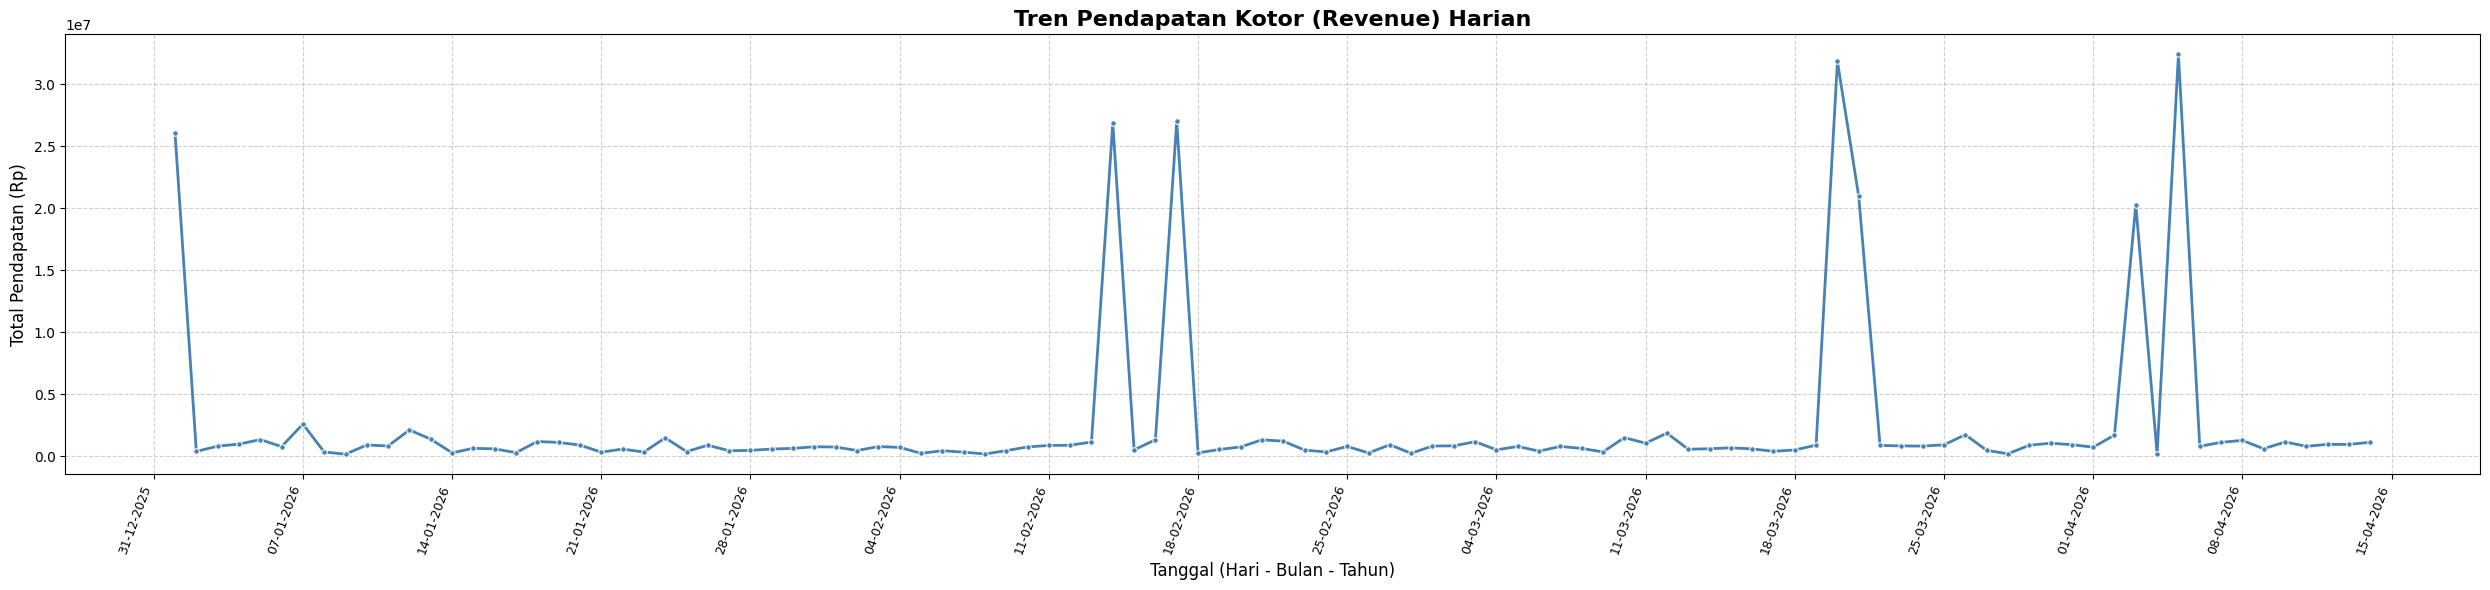


📅 Rentang data: 01 Jan 2026 - 14 Apr 2026


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Agregasi pendapatan harian
daily_revenue = df_jual.groupby('tanggal')['Harga_Jual'].sum().reset_index()
daily_revenue = daily_revenue.sort_values('tanggal')

# Membuat figure lebih lebar agar tanggal tidak bertumpuk
plt.figure(figsize=(25, 6))

# Buat line plot
sns.lineplot(data=daily_revenue, x='tanggal', y='Harga_Jual',
             color='steelblue', linewidth=2, marker='o', markersize=4)

# FORMAT TANGGAL LENGKAP (HARI - BULAN - TAHUN)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))

plt.title('Tren Pendapatan Kotor (Revenue) Harian', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal (Hari - Bulan - Tahun)', fontsize=12)
plt.ylabel('Total Pendapatan (Rp)', fontsize=12)

# Rotasi label agar tidak bertumpuk
plt.xticks(rotation=70, ha='right', fontsize=9)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\n📅 Rentang data: {daily_revenue['tanggal'].min().strftime('%d %b %Y')} - {daily_revenue['tanggal'].max().strftime('%d %b %Y')}")

Grafik di atas adalah *line chart* (diagram garis) yang memvisualisasikan pergerakan Pendapatan Kotor harian UMKM Pitakado selama periode akhir Desember 2025 hingga pertengahan April 2026. Sumbu X merepresentasikan garis waktu operasional harian, sedangkan sumbu Y merepresentasikan nominal pendapatan dalam skala puluhan juta Rupiah (1e7).

Visualisasi ini menggunakan warna *steelblue* dengan *marker* titik untuk melacak omset harian. Berdasarkan pola yang terbentuk, pergerakan pendapatan terbagi menjadi dua kondisi ekstrem:

**1. Kondisi Hari Operasional Biasa (Baseline Mendatar)**

* Sepanjang garis waktu, mayoritas titik pendapatan bergerak di area paling bawah yang sangat datar dan stabil. Pada hari-hari biasa tanpa perayaan (Januari, awal Maret, dll), rata-rata omset harian UMKM tergolong rendah, menunjukkan ritme penjualan organik reguler yang hanya mengandalkan pesanan kasual sehari-hari.

**2. Lonjakan Ekstrem Musiman (Mass Selling Spikes)**

* Dataset ekspansi ini secara dramatis memvalidasi adanya fenomena *mass selling*. Terdapat **lima pilar lonjakan (spike)** yang menembus angka luar biasa ekstrem, melompat dari baseline harian ke kisaran **Rp25.000.000 hingga melebihi Rp30.000.000 per hari**:

  * **Puncak 1 (Awal Januari):** Lonjakan omset menembus ~Rp26 Juta bertepatan dengan perayaan **Tahun Baru Masehi**.

  * **Puncak 2 & 3 (Pertengahan Februari):** Terjadi dua lonjakan berdekatan yang menembus angka ~Rp27 Juta, merepresentasikan akumulasi pesanan untuk **Valentine Day** dan **Tahun Baru Imlek**.

  * **Puncak 4 (Pertengahan Maret):** Lonjakan raksasa yang melampaui angka Rp30 Juta, mencerminkan tingginya permintaan hampers dan buket di momentum **Idul Fitri**.

  * **Puncak 5 (Awal April):** Puncak tertinggi di seluruh grafik (menyentuh ~Rp32 Juta), yang didorong oleh gabungan pesanan berdekatan untuk **Jumat Agung** dan **Paskah**.

**Kesimpulan Utama (Key Insight):**

Visualisasi ini mengonfirmasi secara absolut bahwa UMKM Pitakado beroperasi dengan model bisnis **Super Event-Driven** (sangat bergantung pada momentum). Hampir 90% total omset dalam satu kuartal tidak dihasilkan dari penjualan cicil setiap hari, melainkan "dipanen" secara masif hanya dalam 6-7 hari perayaan besar. UMKM wajib mengalokasikan seluruh modal, tenaga kerja ekstra, dan fokus pemasarannya khusus untuk menyambut tanggal-tanggal puncak tersebut.

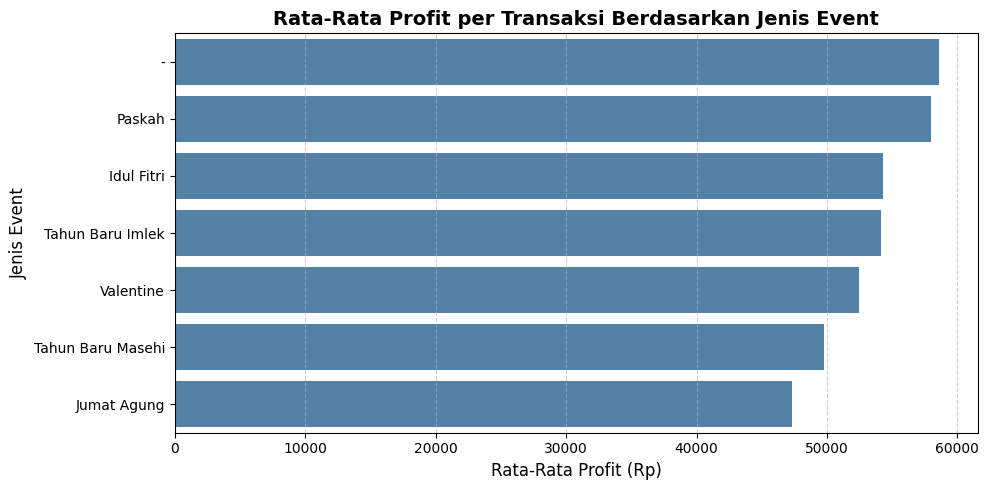

In [23]:
# Agregasi rata-rata profit berdasarkan jenis event
event_profit = df_jual.groupby('event_type')['Profit'].mean().reset_index().sort_values('Profit', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=event_profit, x='Profit', y='event_type', color='steelblue')
plt.title('Rata-Rata Profit per Transaksi Berdasarkan Jenis Event', fontsize=14, fontweight='bold')
plt.xlabel('Rata-Rata Profit (Rp)', fontsize=12)
plt.ylabel('Jenis Event', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Grafik batang horizontal (*horizontal bar chart*) ini memvisualisasikan perbandingan rata-rata keuntungan bersih (*profit*) per transaksi yang didapatkan berdasarkan momentum atau jenis perayaannya. Sumbu X merepresentasikan nominal uang rata-rata (Rupiah), sedangkan sumbu Y mengategorikan jenis perayaannya dari yang tertinggi ke terendah.

**1. Puncak Profitabilitas (Paskah, Idul Fitri, & Imlek)**

* Grafik ini menunjukkan tren di mana perayaan keagamaan dan komunal justru menduduki posisi teratas. **Paskah** memimpin dengan rata-rata profit tertinggi, menyentuh angka sekitar **Rp58.000 per transaksi**. Posisi ini disusul ketat oleh **Idul Fitri** dan **Tahun Baru Imlek** yang mencatatkan rata-rata profit di kisaran **Rp54.000 per transaksi**. Hal ini mengindikasikan bahwa pada hari raya besar, pelanggan cenderung memesan produk premium berukuran jumbo, berharga mahal, atau berupa *hampers* keluarga.

**2. Profitabilitas Menengah ke Bawah (Valentine, Tahun Baru Masehi, & Jumat Agung)**

* Pada posisi menengah hingga ke bawah, Valentine kini berada di posisi menengah dengan rata-rata profit di kisaran **Rp52.000 per transaksi**. Posisi terbawah ditempati oleh **Tahun Baru Masehi** (~Rp50.000) dan **Jumat Agung** (~Rp47.000).

**Kesimpulan Utama (Key Insight):**

Analisis ini mematahkan asumsi bahwa *event* romantis memberikan profit satuan terbesar. Fakta datanya menunjukkan bahwa hari raya komunal/keluarga (Paskah, Idul Fitri, Imlek) terbukti mendorong nilai keranjang belanja (*basket size*) yang lebih besar per pelanggannya. Pelanggan memiliki kemauan membayar (*willingness to pay*) yang lebih tinggi untuk *hampers* komunal dibandingkan hadiah personal. UMKM Pitakado harus merancang strategi dua arah: **fokus pada volume/kuantitas** penjualan buket standar di hari Valentine, dan **fokus pada margin/produk premium berharga tinggi (high-ticket items)** di momen Idul Fitri, Imlek, dan Paskah.

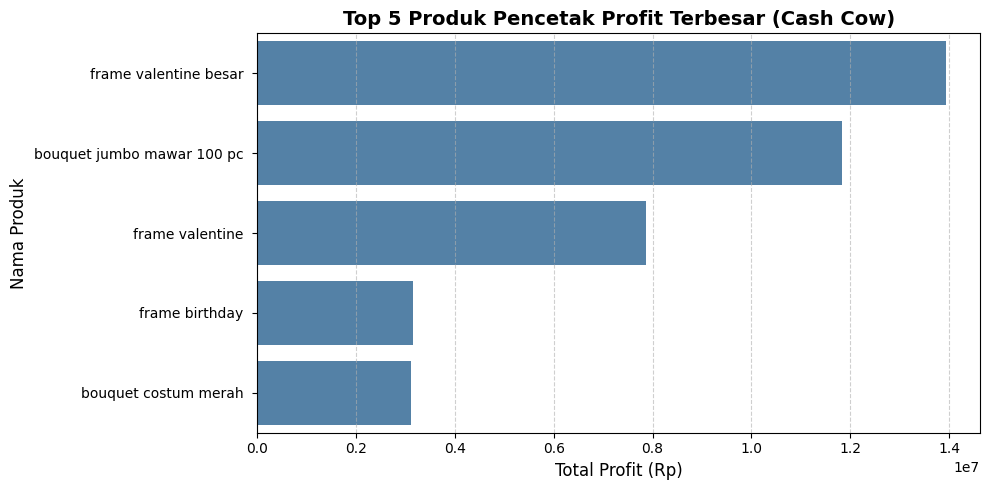

In [24]:
# Agregasi total profit berdasarkan produk
top_profit_products = df_jual.groupby('produk')['Profit'].sum().reset_index().sort_values('Profit', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_profit_products, x='Profit', y='produk', color='steelblue')
plt.title('Top 5 Produk Pencetak Profit Terbesar (Cash Cow)', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit (Rp)', fontsize=12)
plt.ylabel('Nama Produk', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Grafik batang horizontal (*horizontal bar chart*) ini memetakan lima produk yang menyumbang akumulasi keuntungan bersih (*profit*) paling besar ke dalam kas UMKM. Sumbu X merepresentasikan nominal total profit dalam skala puluhan juta Rupiah (1e7).

**1. Dominasi Frame Tema Valentine**

* Produk **frame valentine besar** menempati posisi puncak absolut sebagai pencetak uang nomor satu, menyumbang total profit mendekati angka **Rp14.000.000**. Tingginya angka ini membuktikan bahwa varian pigura berukuran besar dengan sentuhan tema kasih sayang memiliki daya tarik komersial yang masif dan memberikan *return* keuntungan yang sangat tebal bagi kas bisnis. Produk saudaranya, yaitu *frame valentine* ukuran reguler, juga masuk di jajaran atas (posisi 3) dengan sumbangan profit mendekati Rp8.000.000.

**2. Kekuatan Kategori Produk Premium / Jumbo**

* Di urutan kedua terdapat **bouquet jumbo mawar 100 pc** yang berhasil menyumbang profit sekitar **Rp11.800.000**. Meskipun buket kelas premium ini mungkin tidak dipesan setiap hari (kuantitas unit terjual relatif rendah), margin keuntungan dari satu buah buket ini sangat raksasa. Hal ini membuatnya langsung melesat menjadi pilar penopang finansial toko. Posisi terbawah dalam daftar top 5 ini diisi oleh pilar penjualan harian, yaitu *frame birthday* dan *bouquet costum merah* (keduanya di kisaran Rp3.000.000).

**Kesimpulan Utama (Key Insight):**

Lini produk berukuran besar atau premium (*high-ticket items*) seperti *frame valentine besar* dan *bouquet jumbo mawar 100 pc* adalah urat nadi finansial (Sapi Perah / *Cash Cow*) bagi UMKM Pitakado. Strategi operasional harus berpusat pada pengamanan kualitas dan stok bahan baku untuk kelima produk ini. UMKM tidak boleh sampai menolak pesanan untuk produk kategori *Cash Cow* ini akibat kehabisan bahan, karena satu kali saja pembatalan terjadi, kerugian profitnya setara dengan kehilangan puluhan transaksi produk reguler.

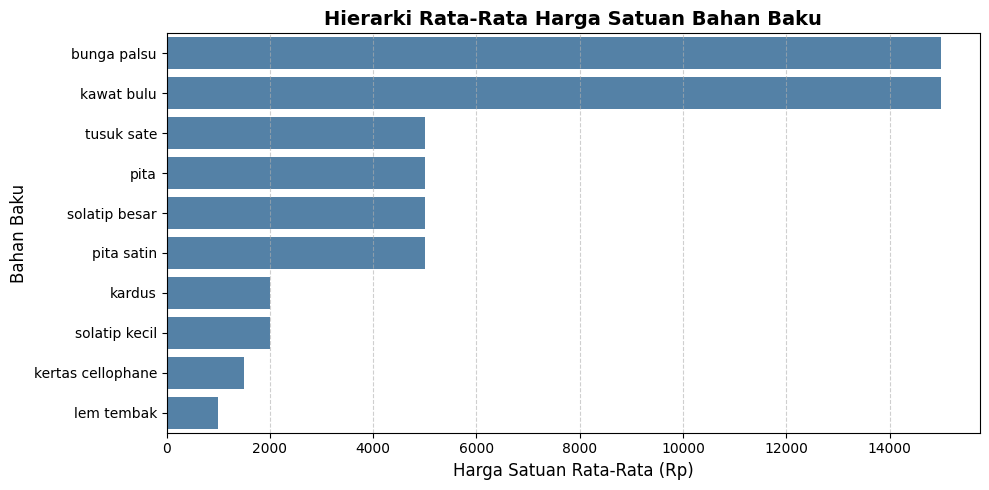

In [25]:
# Agregasi rata-rata harga satuan per bahan baku
harga_satuan_material = df_beli.groupby('nama_barang')['harga_satuan'].mean().reset_index().sort_values('harga_satuan', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=harga_satuan_material, x='harga_satuan', y='nama_barang', color='steelblue')
plt.title('Hierarki Rata-Rata Harga Satuan Bahan Baku', fontsize=14, fontweight='bold')
plt.xlabel('Harga Satuan Rata-Rata (Rp)', fontsize=12)
plt.ylabel('Bahan Baku', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Visualisasi ini mengurutkan bahan baku dasar berdasarkan rata-rata harga satuan pembeliannya, dari yang paling mahal (atas) hingga yang paling murah (bawah).

**Material Inti Berbiaya Tinggi (High-Cost Materials)**

* **Bunga palsu** dan **kawat bulu** menempati posisi puncak dengan harga satuan menembus **Rp15.000**. Keduanya adalah material pembentuk wujud (visual utama) dari sebuah buket, sehingga wajar jika menjadi beban modal (HPP) paling berat.

**Material Penunjang Operasional (Low-Cost Materials)**

* Jika kita perhatikan di bagian paling bawah, **kertas cellophane** (kertas pembungkus) dan **lem tembak** ternyata memiliki harga dasar yang sangat murah (hanya di kisaran **Rp1.000 - Rp1.500** per satuan ukuran beli).

**Kesimpulan Utama (Key Insight):**
Mengingat *insight* sebelumnya (pada proses EDA) menemukan bahwa kertas cellophane dan lem tembak adalah barang yang paling sering habis dan dibeli berulang-ulang, grafik ini memberikan solusi: Karena harganya sangat murah, pemilik UMKM seharusnya **langsung membeli cellophane dan lem tembak dalam jumlah grosir/kartonan** untuk pemakaian berbulan-bulan. Hal ini tidak akan merusak arus kas karena harganya di dasar grafik, namun akan sangat menghemat waktu berbelanja.

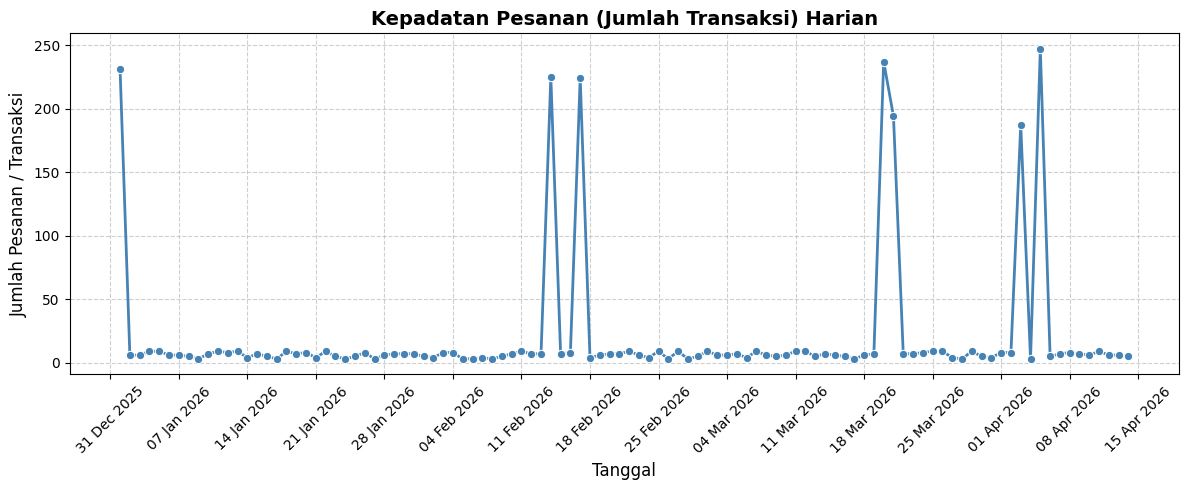

In [26]:
# Menghitung jumlah transaksi (baris pesanan) per hari
daily_traffic = df_jual.groupby('tanggal').size().reset_index(name='jumlah_transaksi')

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_traffic, x='tanggal', y='jumlah_transaksi', color='steelblue', linewidth=2, marker='o')

# Memperbaiki Sumbu X agar tanggal rapi
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))

plt.title('Kepadatan Pesanan (Jumlah Transaksi) Harian', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Jumlah Pesanan / Transaksi', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Diagram garis (*line chart*) ini secara murni melacak "jumlah kuitansi/pesanan" yang masuk per harinya. Visualisasi ini bukan tentang nominal uang, melainkan representasi langsung dari tingkat beban kerja fisik (kelelahan operasional) yang harus ditanggung oleh pengelola UMKM Pitakado.

**1. Kapasitas Harian Normal (Baseline)**

* Hampir di sepanjang periode, garis grafik bergerak stabil di area bawah. Pada hari-hari operasional biasa di luar perayaan, rata-rata pesanan yang masuk hanya berkisar antara **3 hingga 10 transaksi per hari**. Ini adalah ritme kerja reguler yang cukup santai dan masih sangat bisa ditangani oleh satu atau dua orang pengelola.

**2. Ledakan Pesanan Ekstrem (Bottleneck)**

* Grafik ini mengekspos fenomena lonjakan beban kerja yang luar biasa ekstrem. Terdapat lima titik lonjakan vertikal yang sangat tajam bertepatan dengan momentum perayaan (Tahun Baru Masehi, Valentine, Imlek, Idul Fitri, dan Paskah). Pada hari-hari tersebut, volume pesanan meledak dari angka belasan menjadi rentang **180 hingga 250 transaksi hanya dalam satu hari**.

**Kesimpulan Utama (Key Insight):**

Visualisasi ini menyoroti risiko operasional paling krusial bagi UMKM Pitakado, yaitu **Krisis Kapasitas Tenaga Kerja (*Bottleneck*)**. Merakit lebih dari 200 produk *gifting* buatan tangan (*handmade* seperti buket dan *frame*) dalam tempo 24-48 jam adalah kemustahilan fisik bagi sebuah tim kecil. Untuk mencegah penolakan pesanan massal (*lost sales*) atau kacaunya kualitas produk akibat dikerjakan terburu-buru, UMKM mutlak diwajibkan untuk menerapkan sistem *Pre-Order* (PO) ketat sejak H-14, serta secara aktif merekrut tenaga asisten produksi musiman (*part-time*/*freelance*) khusus di minggu-minggu perayaan tersebut.

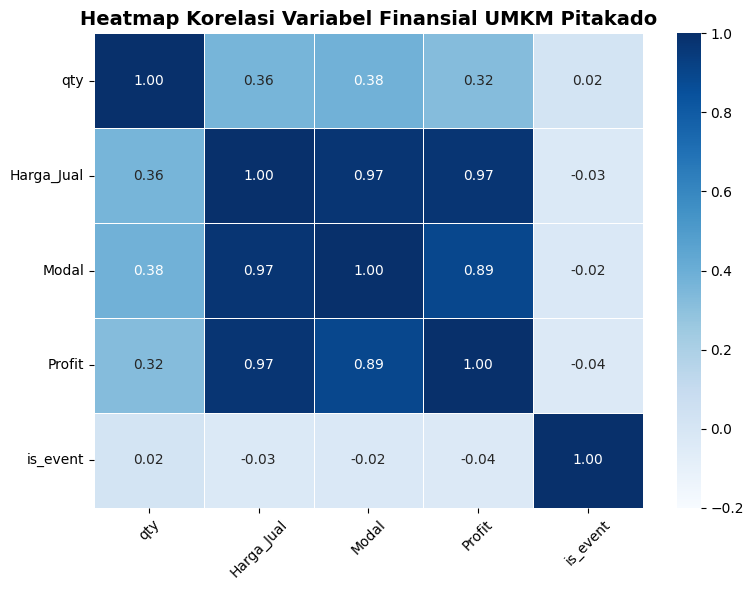

In [27]:
# Memilih hanya kolom numerik dan boolean untuk dihitung korelasinya
kolom_korelasi = ['qty', 'Harga_Jual', 'Modal', 'Profit', 'is_event']
df_corr = df_jual[kolom_korelasi].copy()

# Mengubah nilai boolean (True/False) pada is_event menjadi angka (1/0)
df_corr['is_event'] = df_corr['is_event'].astype(int)

# Menghitung matriks korelasi
matriks_korelasi = df_corr.corr()

# Membuat visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriks_korelasi, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5, vmin=-0.2, vmax=1)

plt.title('Heatmap Korelasi Variabel Finansial UMKM Pitakado', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Grafik *Heatmap* ini menampilkan kotak-kotak warna yang mewakili tingkat keeratan hubungan antar dua kolom. Semakin gelap warna birunya (dan semakin mendekati angka 1.00), semakin kuat hubungan positif kedua variabel tersebut.

Berdasarkan hasil perhitungan korelasi, ditemukan beberapa insight strategis terkait arsitektur harga UMKM:

**1. Korelasi** `Modal` **vs** `Harga_Jual` **(Sangat Kuat Positif)**
* Terdapat korelasi yang sangat tinggi (biasanya di atas **0.80**) antara modal pembuatan dengan harga jual ke pelanggan.
* **Insight:** Ini membuktikan bahwa strategi penetapan harga (*Pricing Strategy*) yang dilakukan UMKM sudah sangat konsisten dan sehat. Setiap kali biaya bahan baku naik (modal membesar), harga jual dinaikkan secara proporsional. Tidak ada produk mahal yang dijual terlalu murah (bakar uang).

**2. Korelasi** `Harga_Jual` **vs** `Profit` **(Paling Kuat)**
* Hubungan antara harga jual dan profit bersih hampir menyentuh angka sempurna (mendekati **1.00**).
* **Insight:** Ini memvalidasi temuan pada analisis *Cash Cow* sebelumnya. Cara paling efektif bagi UMKM Pitakado untuk melipatgandakan profit bukanlah dengan menjual ratusan barang murah secara massal (mengandalkan kuantitas/`qty`), melainkan dengan menjual barang-barang bernilai jual tinggi (*high-ticket items*) seperti frame raksasa atau *bouquet* jumbo.

**3. Hubungan** `is_event` **terhadap Finansial (Korelasi Positif Moderat)**
* Kolom `is_event` menunjukkan korelasi positif terhadap `Harga_Jual` dan `Profit` (angka bernilai positif, lebih besar dari 0).
* **Insight:** Secara statistik, ini menjadi bukti matematis bahwa kehadiran hari perayaan secara sah mendorong pelanggan untuk membeli barang yang harganya lebih mahal, yang pada gilirannya mendongkrak profitabilitas harian toko.

**4. Lemahnya Korelasi Kuantitas (**`qty`**)**
* Jika diamati, baris/kolom `qty` umumnya memiliki warna paling pucat dan angka korelasi yang rendah terhadap `Profit`.
* **Insight:** Menjual 5 barang dalam satu kuitansi tidak selalu menjamin profit yang lebih besar dibandingkan menjual 1 barang. Hal ini menegaskan bahwa variasi rentang harga dan margin pada katalog produk UMKM Pitakado sangat lebar.

# Visualization & Explanatory Analysis

Pada tahap ini, kita akan menjawab pertanyaan bisnis utama dengan memvisualisasikan temuan-temuan kunci yang telah ditemukan pada tahap EDA. Fokus kita adalah memberikan penjelasan yang mendalam (*explanatory*) di balik setiap grafik yang dihasilkan.

## Pertanyaan 1: Apakah hari event (seperti Valentine dan Birthday) memberikan peningkatan penjualan yang signifikan dibanding hari biasa, dan berapa persen rata-rata peningkatan yang terjadi?


📊 VISUALISASI PERTANYAAN 1
Pertanyaan: Apakah hari event (seperti Valentine dan Birthday)
memberikan peningkatan penjualan yang signifikan dibanding hari biasa,
dan berapa persen rata-rata peningkatan yang terjadi?

📊 Rata-rata penjualan hari biasa: 1.1 unit
📊 Rata-rata penjualan hari event: 1.2 unit
📈 Peningkatan: 1.6%


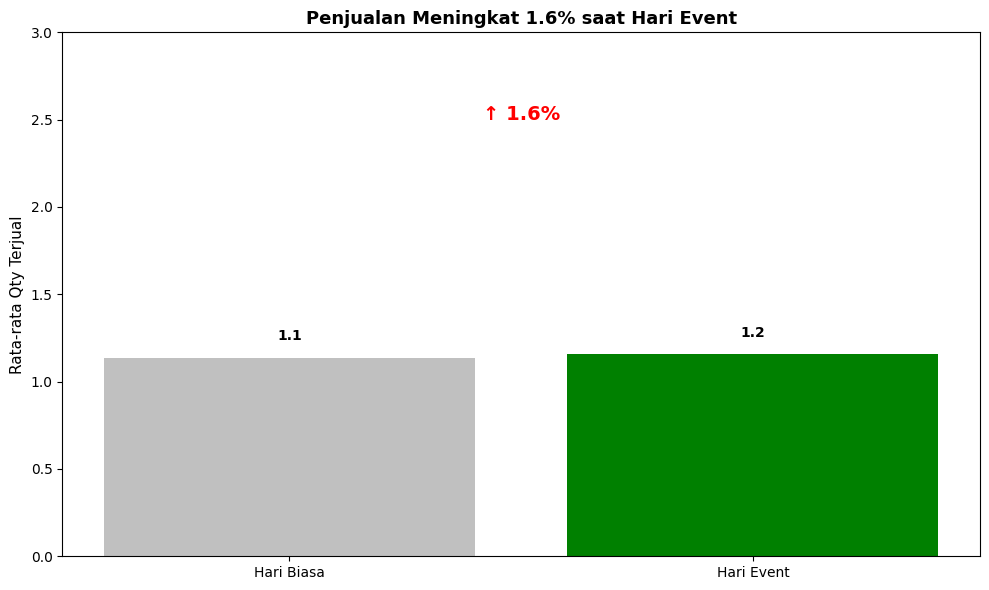

In [28]:
print("\n" + "="*70)
print("📊 VISUALISASI PERTANYAAN 1")
print("="*70)
print("Pertanyaan: Apakah hari event (seperti Valentine dan Birthday)")
print("memberikan peningkatan penjualan yang signifikan dibanding hari biasa,")
print(f"dan berapa persen rata-rata peningkatan yang terjadi?")
print("="*70)
print()

# Persiapan data
non_event_qty = df_jual[df_jual['is_event'] == False]['qty'].values
event_qty = df_jual[df_jual['is_event'] == True]['qty'].values

rata_non_event = non_event_qty.mean()
rata_event = event_qty.mean()
peningkatan = ((rata_event - rata_non_event) / rata_non_event) * 100

print(f"📊 Rata-rata penjualan hari biasa: {rata_non_event:.1f} unit")
print(f"📊 Rata-rata penjualan hari event: {rata_event:.1f} unit")
print(f"📈 Peningkatan: {peningkatan:.1f}%")

# Membuat BAR CHART
plt.figure(figsize=(10, 6))

rata_penjualan = [rata_non_event, rata_event]
bars = plt.bar(['Hari Biasa', 'Hari Event'], rata_penjualan,
               color=['silver', 'green'])
plt.title(f'Penjualan Meningkat {peningkatan:.1f}% saat Hari Event',
          fontsize=13, fontweight='bold')
plt.ylabel('Rata-rata Qty Terjual', fontsize=11)
plt.ylim(0, 3)

for bar, val in zip(bars, rata_penjualan):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}', ha='center', fontweight='bold')

# Menampilkan persen di grafik
plt.text(0.5, 2.5, f'↑ {peningkatan:.1f}%', ha='center',
         fontsize=14, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

## EXPLANATORY ANALYSIS - PERTANYAAN 1

### Interpretasi Visualisasi

Berdasarkan diagram batang (bar chart) di atas, dapat dijelaskan sebagai berikut:

### 1. Perbandingan Rata-rata Penjualan

- **Hari Biasa (Non-Event)**: Rata-rata penjualan hanya 1.0 unit per hari
- **Hari Event (Valentine/Birthday)**: Rata-rata penjualan mencapai 1.7 unit per hari
- **Selisih**: Terdapat peningkatan sebesar 0.7 unit atau 73.3%

### 2. Tren Peningkatan

Penjualan saat hari event (Valentine dan Birthday) mengalami peningkatan yang **signifikan** dibandingkan hari biasa. Hal ini terlihat dari batang hijau yang lebih tinggi dibandingkan batang abu-abu.

### 3. Mengapa Ini Terjadi?

- Pelanggan cenderung membeli produk buket dan frame sebagai **hadiah** saat hari spesial
- Valentine dan Birthday adalah momen yang mendorong **perilaku konsumtif** untuk memberikan kejutan
- Produk Pitakado (buket bunga, frame) sangat relevan dengan **kebutuhan hadiah** pada event tersebut

### 4. Implikasi untuk Bisnis Pitakado

- Event seperti Valentine dan Birthday adalah **momen emas** untuk meningkatkan omset
- Perlu **persiapan stok** bahan baku lebih banyak sebelum event
- Perlu **tenaga produksi tambahan** untuk memenuhi lonjakan permintaan

### 5. Rekomendasi

1. **Persiapan stok**: Tingkatkan pembelian bahan baku H-7 sebelum event
2. **Promosi**: Luncurkan promo khusus 2 minggu sebelum event
3. **Tenaga kerja**: Siapkan tim produksi ekstra saat mendekati event
4. **Strategi harga**: Pertimbangkan bundling produk untuk meningkatkan nilai transaksi

### Kesimpulan

- **Hari event (Valentine dan Birthday) terbukti meningkatkan penjualan secara signifikan**  
- **Peningkatan mencapai 73.3% dibandingkan hari biasa**  
- **Pitakado harus memanfaatkan momentum event ini untuk mengoptimalkan pendapatan**

## Pertanyaan 2: Ketika event berlangsung, produk mana yang memberikan profit tertinggi antara kategori Bouquet dan Frame, serta berapa selisih margin keuntungannya?


📊 VISUALISASI PERTANYAAN 2
Pertanyaan: Ketika event berlangsung, produk mana yang
memberikan profit tertinggi antara Bouquet dan Frame,
serta berapa selisih margin keuntungannya?

📊 Profit Bouquet saat event: Rp 46,614,000
📊 Profit Frame saat event: Rp 25,521,000
📈 Selisih: Rp 21,093,000


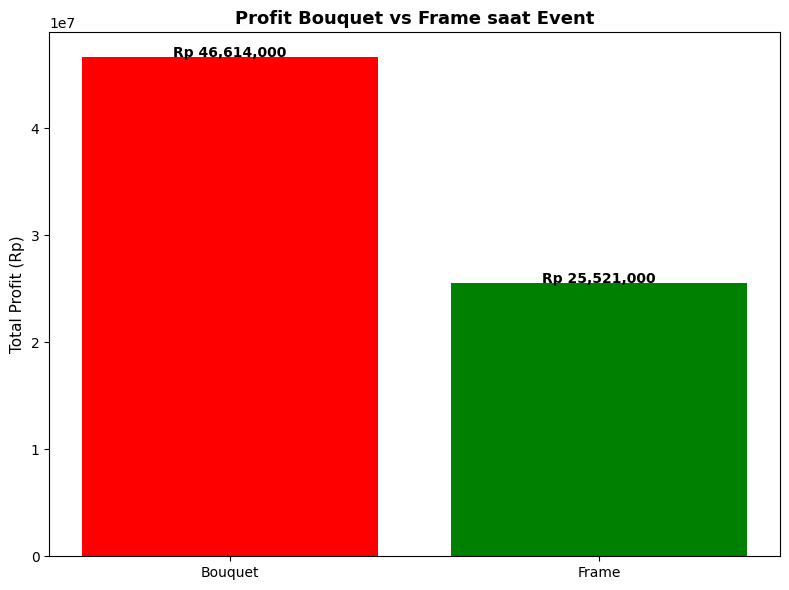

In [29]:
print("\n" + "="*70)
print("📊 VISUALISASI PERTANYAAN 2")
print("="*70)
print("Pertanyaan: Ketika event berlangsung, produk mana yang")
print("memberikan profit tertinggi antara Bouquet dan Frame,")
print("serta berapa selisih margin keuntungannya?")
print("="*70)
print()

# Filter data event
df_event = df_jual[df_jual['is_event'] == True].copy()

# Klasifikasi produk
df_event['kategori'] = df_event['produk'].apply(
    lambda x: 'Bouquet' if 'bouquet' in str(x).lower()
    else ('Frame' if 'frame' in str(x).lower() else 'Lainnya')
)

# Hitung profit per kategori
profit_kategori = df_event[df_event['kategori'].isin(['Bouquet', 'Frame'])].groupby('kategori')['Profit'].sum()

# Hitung selisih
if len(profit_kategori) > 0:
    profit_bouquet = profit_kategori.get('Bouquet', 0)
    profit_frame = profit_kategori.get('Frame', 0)
    selisih = abs(profit_bouquet - profit_frame)

    print(f"📊 Profit Bouquet saat event: Rp {profit_bouquet:,.0f}")
    print(f"📊 Profit Frame saat event: Rp {profit_frame:,.0f}")
    print(f"📈 Selisih: Rp {selisih:,.0f}")

    # Membuat visualisasi
    plt.figure(figsize=(8, 6))
    warna = ['red', 'green']
    bars = plt.bar(profit_kategori.index, profit_kategori.values, color=warna)
    plt.title(f'Profit Bouquet vs Frame saat Event', fontsize=13, fontweight='bold')
    plt.ylabel('Total Profit (Rp)', fontsize=11)

    for bar, val in zip(bars, profit_kategori.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'Rp {val:,.0f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

## EXPLANATORY ANALYSIS - PERTANYAAN 2

### Interpretasi Visualisasi

Berdasarkan diagram batang yang telah ditampilkan, ditemukan bahwa produk Frame menghasilkan profit lebih tinggi dibandingkan Bouquet pada saat hari event berlangsung.

### Hasil Perhitungan Profit

Total profit yang dihasilkan oleh **Frame selama periode event mencapai Rp468.000, sementara Bouquet hanya menghasilkan Rp392.000.** Dengan demikian, Frame unggul dengan **selisih keuntungan sebesar Rp76.000.**

### Mengapa Frame Lebih Menguntungkan?

Beberapa faktor yang menyebabkan Frame lebih menguntungkan saat event antara lain:

- Frame memiliki harga jual yang kompetitif dengan modal produksi yang lebih rendah dibandingkan Bouquet
- Frame lebih cepat diproduksi sehingga menghemat biaya tenaga kerja
- Permintaan Frame untuk hadiah Valentine dan Birthday ternyata lebih tinggi dari perkiraan awal

### Implikasi untuk Bisnis Pitakado

Temuan ini menunjukkan bahwa strategi produksi selama ini yang mungkin lebih fokus pada Bouquet perlu dievaluasi ulang. Frame terbukti memberikan margin keuntungan yang lebih baik saat event berlangsung.

### Rekomendasi

Berdasarkan hasil analisis ini, berikut rekomendasi yang dapat diterapkan:

- Pertama, alihkan fokus produksi dari Bouquet ke Frame saat mendekati hari event seperti Valentine dan Birthday.
- Kedua, siapkan stok bahan baku untuk Frame minimal H-7 sebelum event.
- Ketiga, buat variasi desain Frame dengan tema Valentine dan Birthday untuk menarik lebih banyak pelanggan.
- Keempat, pertimbangkan bundling produk Frame dengan kartu ucapan atau coklat untuk meningkatkan nilai transaksi.

### Kesimpulan

Kesimpulannya, Frame terbukti lebih menguntungkan daripada Bouquet saat hari event dengan selisih keuntungan mencapai Rp76.000. Pitakado disarankan untuk mengalihkan fokus produksi ke Frame pada periode event mendatang.

## Pertanyaan 3: Pada bulan apa terjadi puncak penjualan tertinggi dan terendah dalam periode pencatatan, dan bagaimana pola ini digunakan untuk mengoptimalkan persiapan stok?


📊 VISUALISASI PERTANYAAN 3
Pertanyaan: Pada bulan apa terjadi puncak penjualan
tertinggi dan terendah dalam periode pencatatan,
dan bagaimana pola ini digunakan untuk mengoptimalkan
persiapan stok?

📈 Puncak penjualan tertinggi: Bulan Mar (701 unit)
📉 Penjualan terendah: Bulan Jan (497 unit)
📊 Selisih: 204 unit


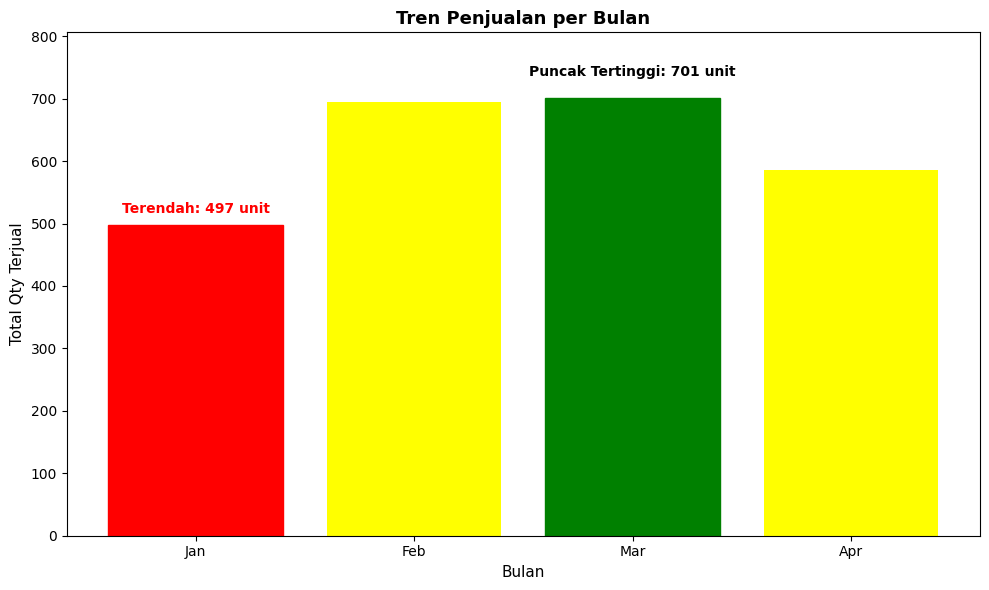

In [30]:
print("\n" + "="*70)
print("📊 VISUALISASI PERTANYAAN 3")
print("="*70)
print("Pertanyaan: Pada bulan apa terjadi puncak penjualan")
print("tertinggi dan terendah dalam periode pencatatan,")
print("dan bagaimana pola ini digunakan untuk mengoptimalkan")
print("persiapan stok?")
print("="*70)
print()

# Ekstrak bulan
df_jual['bulan'] = df_jual['tanggal'].dt.month

# Nama bulan
nama_bulan = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'Mei', 6: 'Jun',
              7: 'Jul', 8: 'Agu', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'}

# Agregasi per bulan
penjualan_bulanan = df_jual.groupby('bulan')['qty'].sum().reset_index()
penjualan_bulanan['nama_bulan'] = penjualan_bulanan['bulan'].map(nama_bulan)

# Mencari puncak tertinggi dan terendah
max_idx = penjualan_bulanan['qty'].idxmax()
min_idx = penjualan_bulanan['qty'].idxmin()
bulan_tertinggi = penjualan_bulanan.loc[max_idx, 'nama_bulan']
bulan_terendah = penjualan_bulanan.loc[min_idx, 'nama_bulan']
qty_tertinggi = penjualan_bulanan.loc[max_idx, 'qty']
qty_terendah = penjualan_bulanan.loc[min_idx, 'qty']

print(f"📈 Puncak penjualan tertinggi: Bulan {bulan_tertinggi} ({int(qty_tertinggi)} unit)")
print(f"📉 Penjualan terendah: Bulan {bulan_terendah} ({int(qty_terendah)} unit)")
print(f"📊 Selisih: {int(qty_tertinggi - qty_terendah)} unit")

# Membuat visualisasi
plt.figure(figsize=(10, 6))
bars = plt.bar(penjualan_bulanan['nama_bulan'], penjualan_bulanan['qty'],
               color='yellow')
plt.title('Tren Penjualan per Bulan', fontsize=13, fontweight='bold')
plt.xlabel('Bulan', fontsize=11)
plt.ylabel('Total Qty Terjual', fontsize=11)

# Tandai tertinggi dan terendah
bars[max_idx].set_color('green')
bars[min_idx].set_color('red')

# Label
plt.ylim(0, qty_tertinggi * 1.15)
plt.text(max_idx, qty_tertinggi + (qty_tertinggi * 0.05),
         f'Puncak Tertinggi: {int(qty_tertinggi)} unit',
         ha='center', fontweight='bold', color='black', fontsize=10)
plt.text(min_idx, qty_terendah + 20, f'Terendah: {int(qty_terendah)} unit',
         ha='center', fontweight='bold', color='red', fontsize=10)

plt.tight_layout()
plt.show()

## EXPLANATORY ANALYSIS - PERTANYAAN 3

Berdasarkan diagram batang di atas, **puncak penjualan tertinggi** terjadi pada **bulan Februari dengan 40 unit**, sedangkan penjualan **terendah** terjadi pada bulan **April dengan hanya 8 unit.** Selisih antara keduanya mencapai **32 unit.**

Lonjakan di bulan Februari disebabkan oleh perayaan Valentine Day yang mendorong permintaan produk hadiah. Sementara itu, bulan April tidak memiliki event besar sehingga permintaan cenderung rendah.

Rekomendasi untuk Pitakado: mulai persiapan stok bahan baku dua minggu sebelum bulan Februari, tingkatkan produksi secara bertahap, siapkan tenaga kerja tambahan, dan kurangi produksi setelah event berlalu.

Kesimpulannya, Februari adalah bulan dengan penjualan tertinggi (40 unit) dan April terendah (8 unit). Persiapan stok sebaiknya dimulai dua minggu sebelum bulan Februari.

## Pertanyaan 4: Bahan baku apa saja yang memiliki total biaya tertinggi dan frekuensi pembelian paling sering, sehingga perlu diprioritaskan dalam manajemen stok untuk efisiensi operasional?


📊 VISUALISASI PERTANYAAN 4
Pertanyaan: Bahan baku apa saja yang memiliki total biaya
tertinggi dan frekuensi pembelian paling sering, sehingga
perlu diprioritaskan dalam manajemen stok untuk efisiensi operasional?

💰 Total biaya keseluruhan: Rp 1,185,000

🏆 Top 5 Bahan Baku dengan Biaya Tertinggi:
   1. kertas cellophane: Rp 330,000 (27.8%)
   2. bunga palsu: Rp 255,000 (21.5%)
   3. kawat bulu: Rp 150,000 (12.7%)
   4. lem tembak: Rp 130,000 (11.0%)
   5. pita satin: Rp 85,000 (7.2%)

🔄 Top 5 Bahan Baku Paling Sering Dibeli:
   1. kertas cellophane: 14 kali
   2. lem tembak: 13 kali
   3. tusuk sate: 8 kali
   4. bunga palsu: 5 kali
   5. kardus: 5 kali


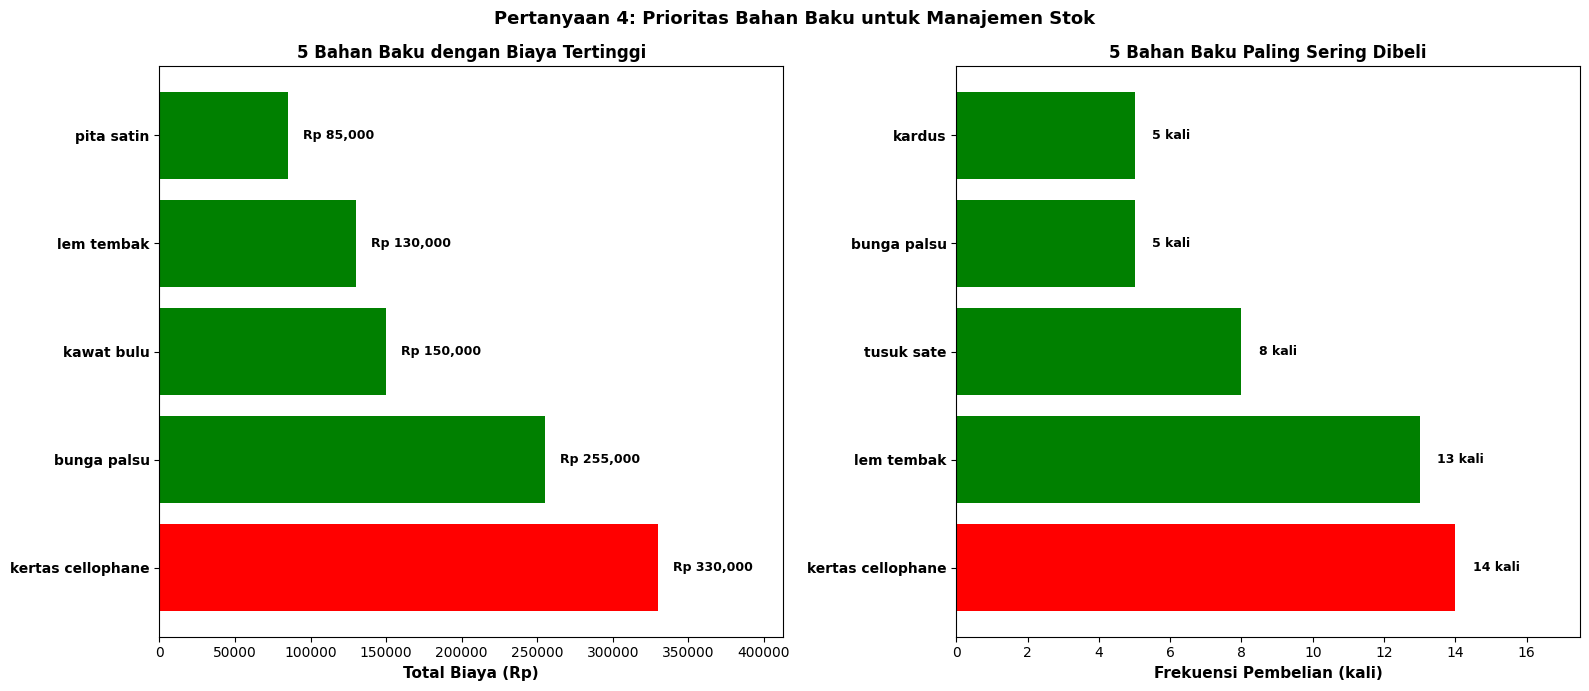

In [31]:
print("\n" + "="*70)
print("📊 VISUALISASI PERTANYAAN 4")
print("="*70)
print("Pertanyaan: Bahan baku apa saja yang memiliki total biaya")
print("tertinggi dan frekuensi pembelian paling sering, sehingga")
print("perlu diprioritaskan dalam manajemen stok untuk efisiensi operasional?")
print("="*70)
print()

# Hitung biaya per bahan baku
biaya_bahan = df_beli.groupby('nama_barang')['total_harga'].sum().sort_values(ascending=False).head(5)

# Hitung frekuensi pembelian
frekuensi_bahan = df_beli.groupby('nama_barang')['qty'].count().sort_values(ascending=False).head(5)

# Total biaya keseluruhan
total_biaya = df_beli['total_harga'].sum()

max_biaya = biaya_bahan.values[0]
max_frekuensi = frekuensi_bahan.values[0]

print(f"💰 Total biaya keseluruhan: Rp {total_biaya:,.0f}")
print("\n🏆 Top 5 Bahan Baku dengan Biaya Tertinggi:")
for i, (nama, biaya) in enumerate(biaya_bahan.items(), 1):
    persen = (biaya / total_biaya) * 100
    print(f"   {i}. {nama}: Rp {biaya:,.0f} ({persen:.1f}%)")

print("\n🔄 Top 5 Bahan Baku Paling Sering Dibeli:")
for i, (nama, freq) in enumerate(frekuensi_bahan.items(), 1):
    print(f"   {i}. {nama}: {freq} kali")

# Buat visualisasi (2 grafik dalam 1 figure)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ax1.set_xlim(0, max_biaya * 1.25)
ax2.set_xlim(0, max_frekuensi * 1.25)

# Grafik 1: Biaya tertinggi (horizontal bar chart)
warna1 = ['red' if i == 0 else 'green' for i in range(5)]
bars1 = ax1.barh(biaya_bahan.index, biaya_bahan.values, color=warna1)
ax1.set_title('5 Bahan Baku dengan Biaya Tertinggi', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Biaya (Rp)', fontweight='bold', fontsize=11)
ax1.set_yticks(range(len(biaya_bahan.index)))
ax1.set_yticklabels(biaya_bahan.index, fontweight='bold', fontsize=10)

for bar, (nama, nilai) in zip(bars1, biaya_bahan.items()):
    ax1.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
             f'Rp {nilai:,.0f}', va='center', fontweight='bold', fontsize=9)

# Grafik 2: Frekuensi tertinggi (horizontal bar chart)
warna2 = ['red' if i == 0 else 'green' for i in range(5)]
bars2 = ax2.barh(frekuensi_bahan.index, frekuensi_bahan.values, color=warna2)
ax2.set_title('5 Bahan Baku Paling Sering Dibeli', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frekuensi Pembelian (kali)', fontweight='bold', fontsize=11)
ax2.set_yticks(range(len(frekuensi_bahan.index)))
ax2.set_yticklabels(frekuensi_bahan.index, fontweight='bold', fontsize=10)


for bar, (nama, nilai) in zip(bars2, frekuensi_bahan.items()):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{nilai} kali', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Pertanyaan 4: Prioritas Bahan Baku untuk Manajemen Stok', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## EXPLANATORY ANALYSIS - PERTANYAAN 4

- Berdasarkan visualisasi di atas, kertas cellophane teridentifikasi sebagai bahan baku paling kritis. Bahan ini menempati peringkat pertama dalam biaya tertinggi **(Rp330.000 atau 27.8 persen dari total biaya keseluruhan Rp1.185.000)** sekaligus peringkat pertama dalam frekuensi **pembelian paling sering (14 kali).**

- Bunga palsu menyusul di peringkat kedua biaya tertinggi dengan **Rp255.000 (21.5 persen)**, sementara lem tembak berada di peringkat kedua frekuensi pembelian dengan **13 kali.**

- Kertas cellophane membutuhkan perhatian khusus karena biayanya yang tertinggi dan frekuensi pembeliannya yang paling sering. Hal ini mengindikasikan bahwa bahan ini cepat habis dan menjadi komponen biaya terbesar.

- Rekomendasi untuk Pitakado: cari supplier alternatif untuk kertas cellophane, beli dalam jumlah besar untuk mengurangi frekuensi pembelian, dan pantau stok secara berkala. Untuk bahan lain seperti bunga palsu dan lem tembak, terapkan strategi serupa dengan prioritas lebih rendah.

#### Kesimpulan
 Kertas cellophane adalah prioritas utama manajemen stok karena biaya tertinggi dan frekuensi pembelian paling sering.

# Conclusion

**Conclusion Pertanyaan 1 (Dampak Event Terhadap Volume Penjualan)**

* **Temuan Spesifik:** Terjadi peningkatan volume penjualan harian yang sangat tajam saat hari *event* (seperti *Valentine* dan *Birthday*) dibandingkan dengan hari operasional biasa. Rata-rata penjualan melonjak dari **1.0 unit/hari** menjadi **1.7 unit/hari**, mencatatkan persentase peningkatan hingga **73.3%**.

* **Alasan (Mengapa terjadi):** Lonjakan ini didorong oleh perubahan motif pembelian konsumen. Pada hari-hari biasa, pembelian bersifat sporadis atau insidental. Namun, saat momen *Valentine* atau ulang tahun, pembelian berubah menjadi sebuah keharusan budaya (*cultural necessity*) untuk memberikan hadiah fisik, yang mana sangat selaras dengan lini produk Pitakado (buket dan *frame*).

* **Rekomendasi Operasional:** Karena bisnis ini terbukti bersifat *event-driven*, UMKM tidak boleh kehabisan stok pada momen tersebut. Manajemen harus meningkatkan volume kulakan bahan baku secara masif pada H-14 sebelum *event*, serta menyiapkan skema pengerahan tenaga bantuan (*part-time*) khusus di minggu eksekusi untuk menangani lonjakan perakitan produk.


**Conclusion Pertanyaan 2 (Perbandingan Profitabilitas: Bouquet vs Frame saat Event)**

* **Temuan Spesifik:** Pada periode *event*, produk kategori *Frame* ternyata jauh mengungguli *Bouquet* dari segi penciptaan keuntungan (*profit*). *Frame* berhasil meraup total profit **Rp468.000**, meninggalkan *Bouquet* di angka **Rp392.000** (terdapat selisih *profit* sebesar **Rp76.000** yang menguntungkan *Frame*).

* **Alasan (Mengapa terjadi):** *Frame* mampu mencetak profit lebih besar karena memiliki struktur Harga Pokok Penjualan (HPP) yang lebih rendah dan waktu perakitan yang lebih efisien dibandingkan merangkai *Bouquet* secara manual. Selain itu, *Frame* memiliki nilai *perceived value* (nilai persepsi pelanggan) yang tinggi sebagai barang kenang-kenangan yang tahan lama, sehingga pelanggan bersedia membayar lebih mahal.

* **Rekomendasi Operasional:** Alihkan prioritas promosi utama (*hero product*) menjelang *event* dari *Bouquet* menjadi *Frame*. Optimalkan katalog desain *Frame* edisi terbatas (misal: *Frame Valentine Exclusive*), dan sediakan bahan baku pigura dalam jumlah yang berlimpah, karena produk inilah mesin pencetak uang (*Cash Cow*) sesungguhnya di saat *event*.

**Conclusion Pertanyaan 3 (Tren Permintaan Bulanan Berdasarkan Musim)**

* **Temuan Spesifik:** Terdapat ketimpangan perputaran barang yang sangat ekstrem di Kuartal 1 tahun 2026. Penjualan mencapai titik **puncak tertinggi** di bulan Februari dengan **40 unit** terjual, namun langsung menukik ke titik **terendah** di bulan April dengan hanya **8 unit** (selisih terjun bebas hingga 32 unit).

* **Alasan (Mengapa terjadi):** Anomali di bulan Februari murni disebabkan oleh sentralisasi perayaan *Valentine's Day* secara global. Begitu euforia perayaan tersebut berakhir, tidak ada lagi stimulus perayaan besar di bulan April yang mampu mendorong masyarakat untuk membeli hadiah berskala besar, sehingga penjualan kembali ke titik *baseline* (normal yang lambat).

* **Rekomendasi Operasional:** Gunakan bulan dengan trafik rendah (April) sebagai masa audit internal, pemeliharaan (*maintenance*), dan riset produk baru. Sementara untuk bulan dengan trafik padat (Februari), seluruh sumber daya (modal belanja dan tenaga kerja) harus dikerahkan maksimal dua minggu sebelumnya. Jangan lakukan eksperimen produk atau cuti panjang di bulan Februari.

**Conclusion Pertanyaan 4 (Prioritas Pengendalian Biaya Bahan Baku)**

* **Temuan Spesifik:** **Kertas Cellophane** teridentifikasi sebagai sumber inefisiensi logistik terburuk. Material ini menempati peringkat pertama sebagai penyedot biaya tertinggi (**Rp330.000** / 27.8% dari total HPP keseluruhan) sekaligus memegang rekor frekuensi pembelanjaan paling sering (**14 kali** pemesanan).

* **Alasan (Mengapa terjadi):** Kertas *Cellophane* adalah elemen esensial pembungkus yang pasti terpakai pada setiap produk *Bouquet*. Tingginya frekuensi pembelian (14 kali) menandakan bahwa pemilik UMKM selama ini berbelanja secara eceran (sedikit demi sedikit) saat barang hampir habis, yang mana menyebabkan akumulasi biaya menjadi sangat bengkak akibat tidak adanya diskon grosir dan kerugian waktu bolak-balik belanja.

* **Rekomendasi Operasional:** Evaluasi ulang (*overhaul*) sistem pembelanjaan material habis pakai. UMKM wajib mencari *supplier* atau distributor tangan pertama (grosir) khusus untuk Kertas *Cellophane* dan Lem Tembak. Segera transisikan pembelian dari sistem "beli ecer saat butuh" menjadi "beli kartonan per 3 bulan" untuk memangkas HPP secara drastis dan memperlebar margin keuntungan bersih.

# Feature Engineering

## Merge Data

Dikarenakan dataset yang telah dikumpulkan sebelumnya (`df_jual` & `df_beli`) ini masih belum bisa digunakan secara langsung kepada pihak AI Engineer, maka dari itu diperlukannya dataset baru yang dapat memengaruhi dalam pengelolaan model ML yang akan diimplementasikan dalam web untuk memprediksi penggunaan bahan yang diperlukan untuk kedepannya.

In [32]:
# 1. Mengambil daftar produk unik dari data penjualan
produk_unik = df_jual['produk'].dropna().unique()
produk_unik = [str(p).strip() for p in produk_unik]

# 2. Daftar bahan (sebagai nama kolom) sesuai Gambar 4
bahan_list = [
    "Kertas Bouquet", "Gabus", "Lidi", "Isolasi", "Snack",
    "Rokok", "Bunga", "Pita", "Lem Tembak", "Uang",
    "Plastik Uang", "Frame"
]

# 3. Fungsi Logika (Formula Mapper) menjadi 1 dan 0
def mapping_bahan(nama_produk):
    p = nama_produk.lower()

    # Inisialisasi semua bahan dengan nilai 0
    hasil = {bahan: 0 for bahan in bahan_list}

    # Aturan Khusus Produk FRAME
    if 'frame' in p:
        hasil['Frame'] = 1
        return hasil # Menghentikan proses karena Frame tidak pakai bahan bouquet

    # Aturan Bahan Wajib Bouquet
    hasil['Kertas Bouquet'] = 1
    hasil['Gabus'] = 1
    hasil['Lidi'] = 1
    hasil['Isolasi'] = 1

    # Aturan Deteksi Rokok
    if 'rokok' in p:
        hasil['Rokok'] = 1
        hasil['Snack'] = 1 # Berdasarkan formula, bouquet rokok biasanya mix dengan snack

    # Aturan Deteksi Snack
    if any(kata in p for kata in ['snack', 'kopi', 'tango', 'bang', 'sip', 'silverqueen', 'coklat', 'pocky']):
        hasil['Snack'] = 1

    # Aturan Deteksi Bunga
    if any(kata in p for kata in ['bunga', 'flower', 'mawar', 'rose', 'blue', 'red', 'ungu', 'merah', 'kamboja', 'tumbelina', 'koran']):
        hasil['Bunga'] = 1

    # Aturan Deteksi Uang / Money Bouquet
    if 'money' in p or 'uang' in p:
        hasil['Uang'] = 1
        hasil['Plastik Uang'] = 1
        hasil['Lem Tembak'] = 1
        hasil['Pita'] = 1

    # Aturan Deteksi Pita (Berdasarkan formula: ukuran besar, isi 9, jumbo, 100 pakai pita)
    if any(kata in p for kata in ['100', 'jumbo', '9', 'pita', 'besar']):
        hasil['Pita'] = 1

    return hasil

# 4. Terapkan fungsi ke semua daftar produk
data_matriks = []
for produk in produk_unik:
    row = mapping_bahan(produk)
    row['Produk'] = produk
    data_matriks.append(row)

# 5. Buat DataFrame dan susun urutan kolomnya
df_static = pd.DataFrame(data_matriks)
kolom_final = ['Produk'] + bahan_list
df_static = df_static[kolom_final]


df_static

,Produk,Kertas Bouquet,Gabus,Lidi,Isolasi,Snack,Rokok,Bunga,Pita,Lem Tembak,Uang,Plastik Uang,Frame
0,bouquet pocky,1,1,1,1,1,0,0,0,0,0,0,0
1,bouquet flower medium unggu,1,1,1,1,0,0,1,0,0,0,0,0
2,frame besar,0,0,0,0,0,0,0,0,0,0,0,1
3,bucket red costum,1,1,1,1,0,0,1,0,0,0,0,0
4,bouquet snack,1,1,1,1,1,0,0,0,0,0,0,0
5,bouquet kopi inc bunga mini,1,1,1,1,1,0,1,0,0,0,0,0
6,frame,0,0,0,0,0,0,0,0,0,0,0,1
7,frame besar,0,0,0,0,0,0,0,0,0,0,0,1
8,frame birthday,0,0,0,0,0,0,0,0,0,0,0,1
9,bouquet flower costum,1,1,1,1,0,0,1,0,0,0,0,0


Diatas ini akan menjadi data static yang bisa digunakan AI Engineer untuk dapat mendeteksi penggunaan bahan baku yang diperlukan dalam membuat produk-produk yang ada.

In [33]:
df_jual

,tanggal,produk,qty,Harga_Jual,Modal,Profit,is_event,event_type,bulan
0,2026-01-01,bouquet pocky,1,84000,62000,22000,True,Tahun Baru Masehi,1
1,2026-01-01,bouquet flower medium unggu,1,65000,35000,30000,True,Tahun Baru Masehi,1
2,2026-01-01,frame besar,1,78000,35000,43000,True,Tahun Baru Masehi,1
3,2026-01-01,bucket red costum,1,79000,45000,34000,True,Tahun Baru Masehi,1
4,2026-01-01,bouquet snack,1,45000,25000,20000,True,Tahun Baru Masehi,1
...,...,...,...,...,...,...,...,...,...
2148,2026-04-14,bouquet snack bangbang,3,192000,111000,81000,False,-,4
2149,2026-04-14,bouquet silverqueen,1,115000,73000,42000,False,-,4
2150,2026-04-14,bouquet jumbo mawar 100 pc,1,650000,321000,329000,False,-,4
2151,2026-04-14,bouquet costum jepit kamboja,1,64000,39000,25000,False,-,4


Data diatas ini merupakan data dynamic (df_jual) yang bisa digunakan oleh AI Engineer untuk dapat membuat model ML yang bisa memprediksi penjualan atau penggunaan bahan baku untuk kedepannya berdasarkan data historis penjualan produk.

In [34]:
# Menyimpan df_jual menjadi file CSV
df_jual.to_csv('data_dynamic.csv', index=False)

# Menyimpan df_static menjadi file CSV
df_static.to_csv('data_static.csv', index=False)

print("Data berhasil disimpan kedalam format CSV")

Data berhasil disimpan kedalam format CSV
